**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Recuperatorio- Primer Examen Parcial**

*25 de Noviembre, 2025*




---


Nombre y Apellido:

---



Número de registro:

---



In [236]:
# Importo Librerías
import pandas as pd
import numpy as np
import pulp
import sympy as sp
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

## **Ejercicio 1**

Sos analista en un centro de atención al cliente que monitorea 5 métricas de calidad (A: Llamadas atendidas por día (número de llamadas), B: Tiempo promedio de las llamadas (en minutos), C: Clientes satisfechos (número de clientes que dieron "like" al servicio)) durante 30 días. Vas a simular los datos y trabajar con ellos.

- Crear una tabla con los días y las métricas. Generar datos aleatorios para cada día.

In [237]:
'''
A: Llamadas atendidas por día
B: tiempo en minutos
C: clientes satisfechos
date: fecha
'''
np.random.seed(42)
columns = ['fechas', 'A', 'B', 'C']
fecha_inicial = '2024-01-01'
dias = 30
fechas = pd.date_range(fecha_inicial, periods=dias)
tabla = {
    'fechas': fechas,
    'A': np.random.randint(1, 100, 30),
    'B': np.random.randint(1, 10, 30),
    'C': np.random.randint(10, 100, 30),
}

df = pd.DataFrame(tabla, columns=columns)
df.head()


,fechas,A,B,C
0,2024-01-01,52,3,13
1,2024-01-02,93,7,63
2,2024-01-03,15,4,72
3,2024-01-04,72,9,27
4,2024-01-05,61,3,99


- Calcular el total de cada métrica en los 30 días. Crear una columna/fila adicional que contenga este dato.

In [238]:
df['Total'] = df.sum(axis=1, numeric_only=True)

- Identificar el día con más llamadas y el día con menos llamadas

In [239]:
# Día con menos llamadas
min_idx = df['A'].idxmin()
dia_min_llamadas = df.iloc[min_idx]['fechas']

print(f"""
Día con menos llamadas: {dia_min_llamadas.strftime('%Y-%m-%d')}
Cantidad de llamadas: {df.iloc[min_idx]['A']}
Índice en el DF: {min_idx}
""")



Día con menos llamadas: 2024-01-16
Cantidad de llamadas: 2
Índice en el DF: 15



In [240]:
# Día con más llamadas
max_idx = df['A'].idxmax()
dia_max_llamadas = df.iloc[max_idx]['fechas']

print(f"""
Día con más llamadas: {dia_max_llamadas.strftime('%Y-%m-%d')}
Cantidad de llamadas: {df.iloc[max_idx]['A']}
Índice en el DF: {max_idx}
""")


Día con más llamadas: 2024-01-02
Cantidad de llamadas: 93
Índice en el DF: 1



- ¿Cuál fue el día con mejor servicio? (más clientes satisfechos)
- ¿Hubo algún día con menos de 60 llamadas atendidas?



In [241]:
# Día con más clientes satisfechos
max_idx = df['C'].idxmax()
dia_max_likes = df.iloc[max_idx]['fechas']

print(f"""
Día con más likes: {dia_max_likes.strftime('%Y-%m-%d')}
Cantidad de likes: {df.iloc[max_idx]['C']}
Índice en el DF: {max_idx}
""")


Día con más likes: 2024-01-05
Cantidad de likes: 99
Índice en el DF: 4



In [242]:
# ¿Día con menos de 60 llamadas? A < 60
res = bool((df['A']  < 60).sum())
print(f'''
¿Hubo algún día con menos de 60 llamadas atendidas? {'Sí' if res else 'No'}
      ''')


¿Hubo algún día con menos de 60 llamadas atendidas? Sí
      


- Supongamos que la empresa estima un costo de $5 por minuto de llamada. Calcular el costo total en tiempo de llamadas para la empresa en esos 30 días.

In [243]:
costo = 5
res = df['B'].sum()*costo
print(f'El costo total en tiempo de llamadas para la empresa en esos 30 días es de ${res}')

El costo total en tiempo de llamadas para la empresa en esos 30 días es de $750


## **Ejercicio 2**

Una mueblería fabrica dos tipos de productos:

Escritorios ejecutivos ($x_1$)

Sillas de oficina ($x_2$)

La empresa busca maximizar sus beneficios sujetos a restricciones de capacidad productiva.

| Recurso     | Escritorio (x1) | Silla (x2) | Disponibilidad |
| ----------- | -----------     |----------- |--------------- |
| Madera      | 4               |         2  |  100m2         |
| Horas-Hombre|	3	              |   2	       |80 h            |
| Pintura     | 2               |  1         | 60h            |

- Resolver con `PuLP` el problema de maximización de beneficio

In [244]:
# PASO 1: Crear el problema de optimización
# LpProblem(nombre, tipo) crea un nuevo problema vacío
# "Beneficios" es solo un nombre descriptivo que elegimos
# LpMaximize indica que queremos MAXIMIZAR la función objetivo
prob = pulp.LpProblem("Beneficios", pulp.LpMaximize)


In [245]:
# PASO 2: Definir las variables de decisión
# LpVariable('nombre') crea una variable que PuLP va a optimizar
# Por defecto, las variables son ≥ 0 (no negativas)
# 'x1' = escritorio
# 'x2' = sillas
x1 = pulp.LpVariable("escritorio", lowBound=0)     # Cantidad de escritorios a producir
x2 = pulp.LpVariable("sillas", lowBound=0)      # Cantidad de sillas a producir


In [246]:
# PASO 3: Definir la función objetivo (lo que queremos maximizar)
# prob += expresión_matemática agrega la función objetivo al problema
# 3*x + 5*y es exactamente la expresión matemática que queremos maximizar
# "Z" es un nombre opcional para identificar la función objetivo

# Cada cultivo aporta diferente beneficio por unidad producida
# 3*x1: cantidad de escritorios (3 escritorios)
# 5*x2: cantidad de sillas (50 sillas)

prob += 3*x1 + 5*x2, "Z"


In [247]:
# PASO 4: Agregar las restricciones (limitaciones del problema)
# prob += restricción agrega una limitación al problema
# La sintaxis es muy similar a escribir matemática: variable operador valor

# Restricción 1: 4x + 2y ≤ 100 (madera)
prob += 4*x1 + 2*x2 <= 100, 'madera'

# Restricción 2: 3x + 3y ≤ 80 (hh)
prob += 3*x1 + 2*x2 <= 80, 'hh'

# Restricción 3: 2x + 1y ≤ 60 (pintura)
prob += 3*x1 + 1*x2 <= 60, 'pintura'


In [248]:
# PASO 5: Resolver el problema de optimización
# Configuramos el solver para que no muestre información técnica (msg=0)
solver = pulp.PULP_CBC_CMD(msg=0)
# solve(solver) ejecuta el algoritmo de optimización y devuelve un código de estado
# El resultado 1 significa que se encontró una solución óptima
prob.solve(solver)

1

In [249]:
# INTERPRETAR LOS RESULTADOS DE PULP

# pulp.LpStatus[] convierte el código numérico a texto legible
# prob.status contiene el estado de la solución (1=óptimo, 0=no factible, etc.)
print("Estado:", pulp.LpStatus[prob.status])

# .varValue contiene el valor óptimo de cada variable después de resolver
# x.varValue es el valor óptimo de la variable x
print("Valor óptimo de x1:", x1.varValue)

# y.varValue es el valor óptimo de la variable y
print("Valor óptimo de x2:", x2.varValue)

# pulp.value(prob.objective) obtiene el valor óptimo de la función objetivo
# Es equivalente a evaluar 3*x.varValue + 5*y.varValue
print("Valor de la función objetivo Z:", pulp.value(prob.objective))

# PASO 6: Mostrar resultados
print("=" * 60)
print("SOLUCIÓN ÓPTIMA DEL PROBLEMA DE LA MUEBLERÍA")
print("=" * 60)
print(f"Estado: {pulp.LpStatus[prob.status]}")
print()

if prob.status == pulp.LpStatusOptimal:
    print("✅ Solución óptima encontrada:")
    print()
    print("PRODUCCIÓN ÓPTIMA:")
    print(f"  📋 Escritorios ejecutivos: {x1.varValue:.1f} unidades")
    print(f"  🪑 Sillas de oficina: {x2.varValue:.1f} unidades")
    print()
    print(f"💰 Beneficio máximo: ${pulp.value(prob.objective):.2f}")
    print()
    
    # Verificación de uso de recursos
    print("📊 USO DE RECURSOS:")
    uso_madera = 4*x1.varValue + 2*x2.varValue
    uso_hh = 3*x1.varValue + 2*x2.varValue
    uso_pintura = 2*x1.varValue + 1*x2.varValue
    
    print(f"  Madera: {uso_madera:.1f}/100 m² ({uso_madera/100*100:.1f}%)")
    print(f"  Horas-Hombre: {uso_hh:.1f}/80 h ({uso_hh/80*100:.1f}%)")
    print(f"  Pintura: {uso_pintura:.1f}/60 h ({uso_pintura/60*100:.1f}%)")
    print()
    
    # Identificar restricciones activas
    print("🔍 ANÁLISIS DE RESTRICCIONES:")
    if uso_madera == 100:
        print("  ⚠️ Madera: RESTRICCIÓN ACTIVA (se usa todo el recurso)")
    if uso_hh == 80:
        print("  ⚠️ Horas-Hombre: RESTRICCIÓN ACTIVA (se usa todo el recurso)")
    if uso_pintura == 60:
        print("  ⚠️ Pintura: RESTRICCIÓN ACTIVA (se usa todo el recurso)")
else:
    print("❌ No se encontró solución óptima")
    print(f"Estado: {pulp.LpStatus[prob.status]}")

print("=" * 60)

Estado: Optimal
Valor óptimo de x1: 0.0
Valor óptimo de x2: 40.0
Valor de la función objetivo Z: 200.0
SOLUCIÓN ÓPTIMA DEL PROBLEMA DE LA MUEBLERÍA
Estado: Optimal

✅ Solución óptima encontrada:

PRODUCCIÓN ÓPTIMA:
  📋 Escritorios ejecutivos: 0.0 unidades
  🪑 Sillas de oficina: 40.0 unidades

💰 Beneficio máximo: $200.00

📊 USO DE RECURSOS:
  Madera: 80.0/100 m² (80.0%)
  Horas-Hombre: 80.0/80 h (100.0%)
  Pintura: 40.0/60 h (66.7%)

🔍 ANÁLISIS DE RESTRICCIONES:
  ⚠️ Horas-Hombre: RESTRICCIÓN ACTIVA (se usa todo el recurso)


- Interpretar los resultados obtenidos

- Graficar el conjunto de soluciones factibles

🎯 MINI GRAFICADORA DE PROGRAMACIÓN LINEAL - VERSIÓN SIMPLE

📊 RESTRICCIONES DEFINIDAS:
   1. 4x + 2y <= 100
   2. 3x + 2y <= 80
   3. 3x + 1y <= 60

🎨 Procesando restricciones...


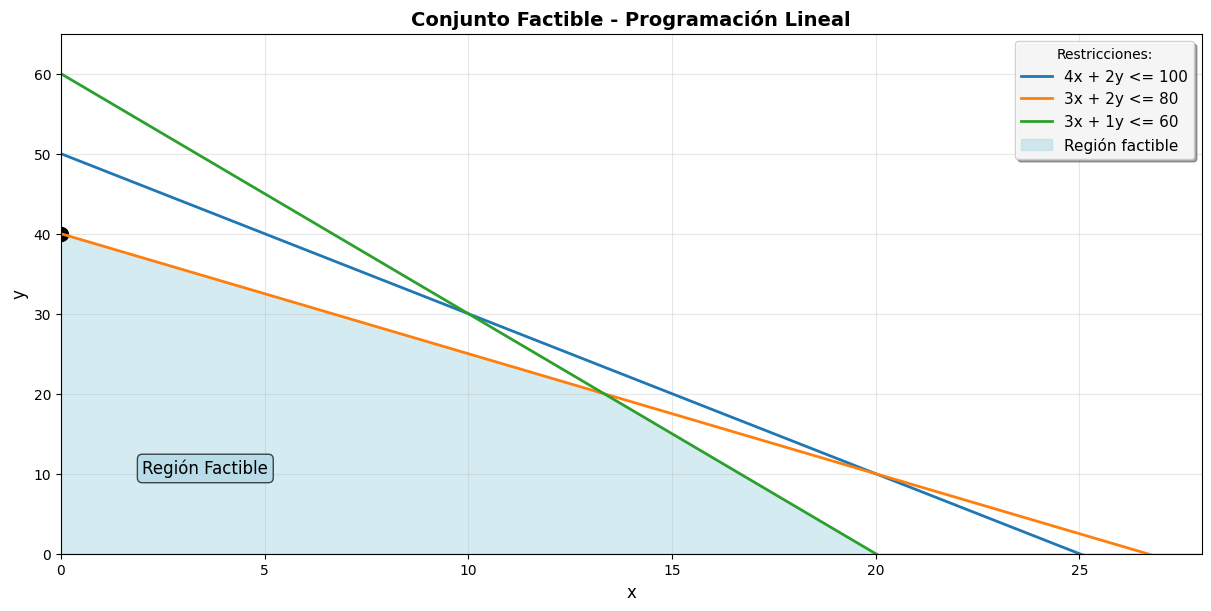

🎉 ¡GRÁFICO COMPLETADO!
📊 La región factible está sombreada en AZUL CLARO
📈 Las líneas de colores son las restricciones
✨ Cualquier punto dentro del área azul es una solución válida



In [250]:
# VERSIÓN SIMPLIFICADA: Define tus restricciones directamente en el código

print("🎯 MINI GRAFICADORA DE PROGRAMACIÓN LINEAL - VERSIÓN SIMPLE")
print("=" * 60)
# print("👆 INSTRUCCIONES: Modifica la lista 'restricciones' debajo")
# print("   Formato: (a, b, c, 'tipo') para a*x + b*y tipo c")
print()

# 📝 MODIFICA ESTA LISTA CON TUS RESTRICCIONES:
# Formato: (a, b, c, 'tipo') donde representa a*x + b*y tipo c
# Ejemplos:
#   (1, 1, 8, '<=')   significa  x + y ≤ 8
#   (2, 1, 10, '<=')  significa  2x + y ≤ 10
#   (1, -1, 0, '>=')  significa  x - y ≥ 0

restricciones = [
    (4, 2, 100, '<='),     # 4x1 + 2x2 ≤ 100
    (3, 2, 80, '<='),    # 3x1 + 2x2 ≤ 80
    (3, 1, 60, '<='),    # 3x1 + 1x2 ≤ 60
]

print("📊 RESTRICCIONES DEFINIDAS:")
for i, (a, b, c, tipo) in enumerate(restricciones, 1):
    print(f"   {i}. {a}x + {b}y {tipo} {c}")
print()

# Resto del código de graficación...
min_x = 0
max_x = 28
min_y = 0
max_y = 65

x = np.linspace(min_x, max_x, 400)
plt.figure(figsize=(12, 6), layout='constrained')

y_todas = []

print("🎨 Procesando restricciones...")
for (a, b, c, tipo) in restricciones:
    if b != 0:
        y = (c - a*x)/b
        y_todas.append((y, tipo))
        plt.plot(x, y, label=f"{a}x + {b}y {tipo} {c}", linewidth=2)
    else:
        x_val = c/a
        plt.axvline(x_val, label=f"{a}x {tipo} {c}", color='red', linewidth=2)

# Calcular región factible
y_factible = np.full_like(x, np.inf)

for (y, tipo) in y_todas:
    if tipo == "<=":
        y_factible = np.minimum(y_factible, y)
    elif tipo == ">=":
        y_factible = np.maximum(y_factible, y)

y_factible = np.maximum(y_factible, 0)

# Graficar
plt.fill_between(x, 0, y_factible, color="lightblue", alpha=0.5, label="Región factible")

# PASO 5: Marcar el punto óptimo

# plt.scatter() dibuja puntos específicos en el gráfico
# ([0], [100]) marca el punto (x=0, y=100) que es nuestra solución óptima
# s=100 define el tamaño del punto, color='black' lo hace negro
plt.scatter([0],[40], s=100, color='black')


plt.xlim(min_x, max_x)
plt.ylim(min_y, max_y)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("Conjunto Factible - Programación Lineal", fontsize=14, fontweight='bold')
plt.legend(
    fontsize=11,
    loc='best',
    shadow=True,
    fancybox=True,
    framealpha=0.9,
    title='Restricciones:',
    )
plt.grid(True, alpha=0.3)

# Agregar anotaciones
plt.text(2, 10, "Región Factible", fontsize=12, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

plt.show()

print("🎉 ¡GRÁFICO COMPLETADO!")
print("📊 La región factible está sombreada en AZUL CLARO")
print("📈 Las líneas de colores son las restricciones")
print("✨ Cualquier punto dentro del área azul es una solución válida")
print()


## **Ejercicio 3**

Una empresa enfrenta las siguientes funciones de demanda y costo medio:



*   $C_{me}(q)=x^2-39.5x+120+\frac{125}{x}$
*   $x-90+2p=0$







Definir el Ingreso y el Beneficio. Simplificar en caso de considerarlo necesario.

Graficar en un mismo gráfico las funciones de Ingreso Total, Costo Total y Beneficio Total. Proveer una interpretación.

## **Ejercicio 4**

Usted posee los siguientes datos de las ventas efectuadas por un almacén pequeño el día de ayer:

| Producto  | Código    | Cantidad  | Precio Unitario
| --------- | --------- | ----------| ---
| Pan x 1kg | 21876171  |  3        | 3000
| Galletitas oreo x3 | 21656171  |  1        | 6000
| Arroz Gallo largo fino x1kg | 34076121  |  2        | 3500
| Pan x 1kg | 21876171  |  2        | 3000
| Salsa tomate 1l | 21870000  |  1        | 2000
| Pan x 1kg | 21876171  |  2        | 3000
| Yerba Piporé Suave x2kg | 21555551  |  1        | 5050
| Galletitas Lincoln | 21876221  |  1        | 1523.5
| Pan x 1kg | 21876171  |  3        | 3000
| Té Green Hills | 11366171  |  5        | 1204
| Fideos Knorr tirabuzón n°34 | 71365671 | 1 | 960
| Arroz Cañuelas largo fino x1kg | 61225673 | 2 | 2200
| Jabón Lux x3 | 71365333 | 1 | 1030
| Galletitas oreo | 21656170 | 2 | 4000
| Salsa tomate 1l | 21870000 | 1 | 2000
| Pan x 1kg | 21876171  |  1        | 3000

Crear un DataFrame con los datos de la tabla

In [251]:
# Datos de las ventas del almacén
datos_ventas = {
    'Producto': [
        'Pan x 1kg',
        'Galletitas oreo x3',
        'Arroz Gallo largo fino x1kg',
        'Pan x 1kg',
        'Salsa tomate 1l',
        'Pan x 1kg',
        'Yerba Piporé Suave x2kg',
        'Galletitas Lincoln',
        'Pan x 1kg',
        'Té Green Hills',
        'Fideos Knorr tirabuzón n°34',
        'Arroz Cañuelas largo fino x1kg',
        'Jabón Lux x3',
        'Galletitas oreo',
        'Salsa tomate 1l',
        'Pan x 1kg'
    ],
    'Codigo': [
        21876171, 21656171, 34076121, 21876171, 21870000,
        21876171, 21555551, 21876221, 21876171, 11366171,
        71365671, 61225673, 71365333, 21656170, 21870000,
        21876171
    ],
    'Cantidad': [3, 1, 2, 2, 1, 2, 1, 1, 3, 5, 1, 2, 1, 2, 1, 1],
    'Precio_Unitario': [
        3000, 6000, 3500, 3000, 2000, 3000, 5050, 1523.5,
        3000, 1204, 960, 2200, 1030, 4000, 2000, 3000
    ]
}

# Crear el DataFrame
df_ventas = pd.DataFrame(datos_ventas)
df_ventas.head()

,Producto,Codigo,Cantidad,Precio_Unitario
0,Pan x 1kg,21876171,3,3000.0
1,Galletitas oreo x3,21656171,1,6000.0
2,Arroz Gallo largo fino x1kg,34076121,2,3500.0
3,Pan x 1kg,21876171,2,3000.0
4,Salsa tomate 1l,21870000,1,2000.0


Crear una columna que contenga el precio total de cada venta individual

In [252]:
df_ventas['Total_Ventas'] = df_ventas['Cantidad'] * df_ventas['Precio_Unitario']
df_ventas.head()

,Producto,Codigo,Cantidad,Precio_Unitario,Total_Ventas
0,Pan x 1kg,21876171,3,3000.0,9000.0
1,Galletitas oreo x3,21656171,1,6000.0,6000.0
2,Arroz Gallo largo fino x1kg,34076121,2,3500.0,7000.0
3,Pan x 1kg,21876171,2,3000.0,6000.0
4,Salsa tomate 1l,21870000,1,2000.0,2000.0


Calcular el ingreso total del día de ayer

In [253]:
ingreso_total = df_ventas['Total_Ventas'].sum()
print(f'''
El ingreso total del día de ayer fue de {ingreso_total}
      ''')


El ingreso total del día de ayer fue de 76983.5
      


Definir una función con nombre `sugerir_reposicion`que devuelva productos que se repiten un mínimo de tres veces en la tabla de ventas. Aplicarla al DataFrame.

In [254]:
def sugerir_reposicion(df):
    # contar apariciones
    conteo = df['Producto'].value_counts()
    # filtrar productos frecuentes
    productos_frecuentes = conteo[conteo >= 3].index
    # agrupar y calcular estadísticas
    resumen = df[df['Producto'].isin(productos_frecuentes)].groupby('Producto').agg({
        'Cantidad': 'sum',         # total de unidades vendidas
        'Total_Ventas': 'sum',     # ingreso total por producto
        'Producto': 'count'        # número de transacciones
    }).rename(columns={'Producto': 'Num_Transacciones'})
    
    return resumen

# aplicar
resumen_reposicion = sugerir_reposicion(df_ventas)
print("Productos que necesitan reposición:")
print(resumen_reposicion)

Productos que necesitan reposición:
           Cantidad  Total_Ventas  Num_Transacciones
Producto                                            
Pan x 1kg        11       33000.0                  5
